# 1 · Stress and strain at a point

Rotate a plane stress state, find its principal stresses, draw Mohr's circle, and check yield
against a MIL-HDBK-5J allowable. Theory: [docs/stress_strain.md](../docs/stress_strain.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from structures import plotting as P

P.use_style()
DEG = np.pi / 180
MPA = 1e6
from structures.stress_strain import (MohrCircle, plot_mohr, principal_2d, max_shear_2d,
                                      transform_stress_2d, von_mises, tresca, safety_factor)
from structures.materials import isotropic, KSI

In [2]:
s = np.array([-20, 90, 60]) * MPA          # sx, sy, txy
s1, s2, tp = principal_2d(s)
tmax, ts = max_shear_2d(s)
print(f"s1 = {s1/MPA:.2f} MPa, s2 = {s2/MPA:.2f} MPa at theta_p = {tp/DEG:.2f} deg")
print(f"max in-plane shear = {tmax/MPA:.2f} MPa at {ts/DEG:.2f} deg")
print("check: shear on the principal plane =", transform_stress_2d(s, tp)[2])

s1 = 116.39 MPa, s2 = -46.39 MPa at theta_p = 66.26 deg
max in-plane shear = 81.39 MPa at 21.26 deg
check: shear on the principal plane = -7.450580596923828e-09


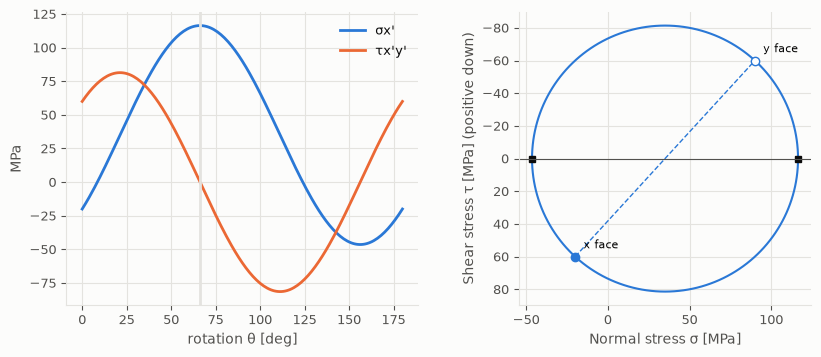

In [3]:
theta = np.linspace(0, np.pi, 181)
sx, sy, txy = transform_stress_2d(s, theta)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.8))
a1.plot(theta / DEG, sx / MPA, label="σx'"); a1.plot(theta / DEG, txy / MPA, label="τx'y'")
a1.axvline(tp / DEG, color=P.GRID); a1.set_xlabel("rotation θ [deg]"); a1.set_ylabel("MPa"); a1.legend()
plot_mohr(a2, MohrCircle(*s), scale=MPA, unit="MPa");

As the element rotates through 180°, the point on Mohr's circle goes once around: a rotation θ of the element is 2θ on the circle.

In [4]:
m = isotropic("2024-T3", "B")
state = np.array([180, 60, 70]) * MPA
print(f"{m.name}: Fty = {m.Fty/KSI:.0f} ksi = {m.Fty/MPA:.0f} MPa ({m.source})")
print(f"von Mises = {von_mises(state)/MPA:.1f} MPa -> SF = {safety_factor(state, m.Fty):.3f}")
print(f"Tresca    = {tresca(state)/MPA:.1f} MPa -> SF = {safety_factor(state, m.Fty, 'tresca'):.3f}")

2024-T3 bare sheet 0.010-0.128 in: Fty = 48 ksi = 331 MPa ([5J-3.2.3.0(b1)])
von Mises = 199.7 MPa -> SF = 1.657
Tresca    = 212.2 MPa -> SF = 1.560
